In [6]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

import sys
sys.path.append('..')
from src.two_layer_xor import TwoLayerXOR

In [20]:
net = TwoLayerXOR()
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y_true = np.array([0, 1, 1, 0])

print("\nNetwork Architecture:")
print(f"W1 (Input→Hidden):\n{net.W1}")
print(f"b1 (Hidden biases): {net.b1}")
print(f"W2 (Hidden→Output):\n{net.W2}")
print(f"b2 (Output bias): {net.b2}")

print("\nXOR Truth Table Verification:")
print(f"{'x1':<5} {'x2':<5} {'Expected':<10} {'Predicted':<10} {'Hidden'}")

for i, (x, y_exp) in enumerate(zip(X, y_true)):
    y_pred, h = net.forward(x)
    print(f"{x[0]:<5} {x[1]:<5} {y_exp:<10} {y_pred[0]:<10} {h[0]}")

is_correct = net.verify_xor()


Network Architecture:
W1 (Input→Hidden):
[[1 1]
 [1 1]]
b1 (Hidden biases): [-1.5 -0.5]
W2 (Hidden→Output):
[[-1]
 [ 1]]
b2 (Output bias): [-0.5]

XOR Truth Table Verification:
x1    x2    Expected   Predicted  Hidden
0     0     0          0          [0 0]
0     1     1          1          [0 1]
1     0     1          1          [0 1]
1     1     0          0          [1 1]


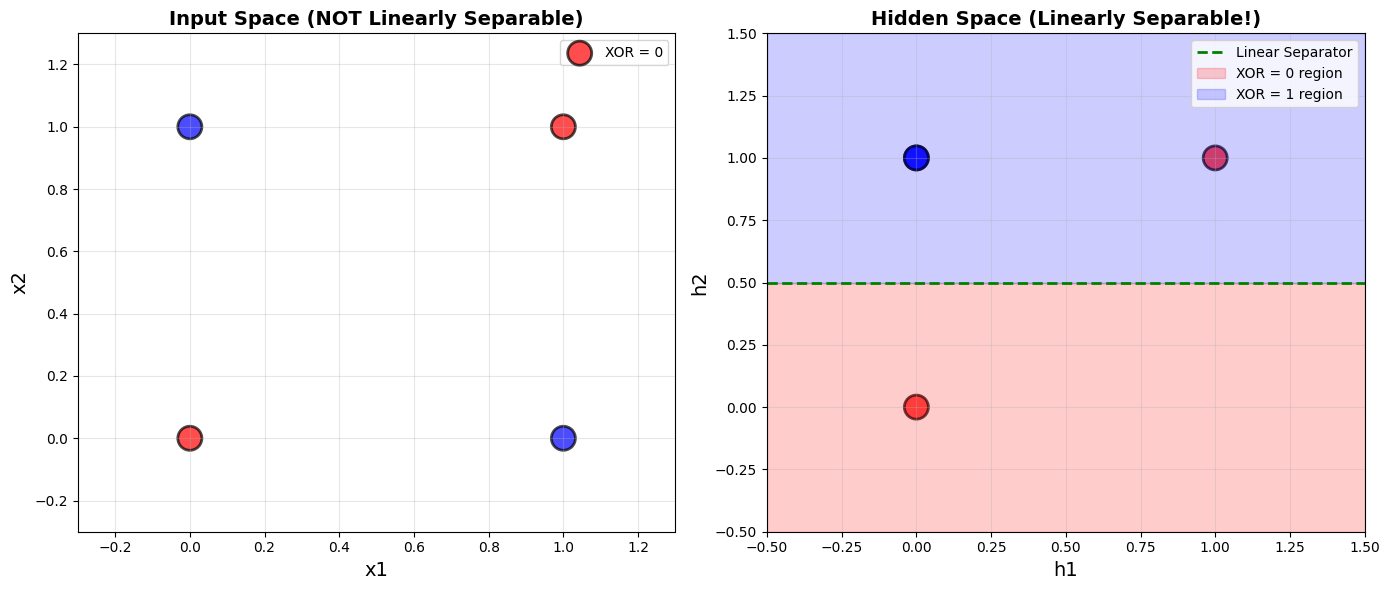

In [21]:
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y_true = np.array([0, 1, 1, 0])

hidden_reps = []
for x in X:
    _, h = net.forward(x)
    hidden_reps.append(h[0])
hidden_reps = np.array(hidden_reps)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
colors = ['red' if y == 0 else 'blue' for y in y_true]
ax1.scatter(X[:, 0], X[:, 1], c=colors, s=300, edgecolors='black', linewidth=2, alpha=0.7)
ax1.set_xlabel('x1', fontsize=14)
ax1.set_ylabel('x2', fontsize=14)
ax1.set_title('Input Space (NOT Linearly Separable)', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.set_xlim(-0.3, 1.3)
ax1.set_ylim(-0.3, 1.3)
ax1.legend(['XOR = 0', 'XOR = 1'], loc='upper right')

ax2.scatter(hidden_reps[:, 0], hidden_reps[:, 1], c=colors, s=300, edgecolors='black', linewidth=2, alpha=0.7)
ax2.plot([-0.5, 1.5], [0.5, 0.5], 'g--', linewidth=2, label='Linear Separator')
ax2.fill_between([-0.5, 1.5], -0.5, 0.5, alpha=0.2, color='red', label='XOR = 0 region')
ax2.fill_between([-0.5, 1.5], 0.5, 1.5, alpha=0.2, color='blue', label='XOR = 1 region')
ax2.set_xlabel('h1', fontsize=14)
ax2.set_ylabel('h2', fontsize=14)
ax2.set_title('Hidden Space (Linearly Separable!)', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.set_xlim(-0.5, 1.5)
ax2.set_ylim(-0.5, 1.5)
ax2.legend(loc='upper right')

plt.tight_layout()
plt.show()

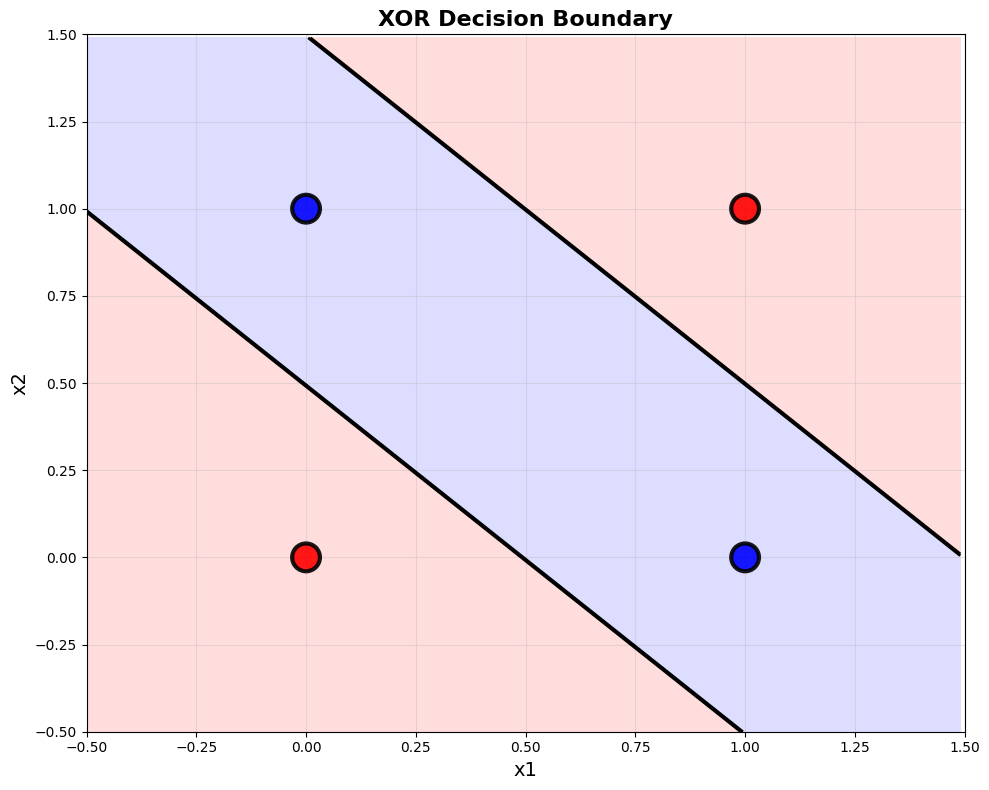

In [27]:
x_min, x_max = -0.5, 1.5
y_min, y_max = -0.5, 1.5
h = 0.01
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                        np.arange(y_min, y_max, h))

grid_points = np.c_[xx.ravel(), yy.ravel()]
Z = net.predict(grid_points)
Z = Z.reshape(xx.shape)

fig, ax = plt.subplots(1, 1, figsize=(10, 8))
cmap = ListedColormap(['#FFAAAA', '#AAAAFF'])
ax.contourf(xx, yy, Z, alpha=0.4, cmap=cmap, levels=1)
ax.contour(xx, yy, Z, colors='black', linewidths=2, levels=1)

X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y_true = np.array([0, 1, 1, 0])
colors = ['red' if y == 0 else 'blue' for y in y_true]
ax.scatter(X[:, 0], X[:, 1], c=colors, s=400, edgecolors='black', linewidth=3, alpha=0.9, zorder=5)
ax.set_xlabel('x1', fontsize=14)
ax.set_ylabel('x2', fontsize=14)
ax.set_title('XOR Decision Boundary', fontsize=16, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)



plt.tight_layout()
plt.show()

In [29]:

configs = [
    {
        'name': 'Original',
        'W1': np.array([[1, 1], [1, 1]]),
        'b1': np.array([-1.5, -0.5]),
        'W2': np.array([[-1], [1]]),
        'b2': np.array([-0.5])
    },
    {
        'name': 'OR-AND based',
        'W1': np.array([[1, 1], [1, 1]]),
        'b1': np.array([-0.5, -1.5]),
        'W2': np.array([[1], [-1]]),
        'b2': np.array([-0.5])
    },
    {
        'name': 'Symmetric',
        'W1': np.array([[1, -1], [-1, 1]]),
        'b1': np.array([-0.5, -0.5]),
        'W2': np.array([[1], [1]]),
        'b2': np.array([-0.5])
    },
    {
        'name': 'Scaled weights',
        'W1': np.array([[2, 2], [2, 2]]),
        'b1': np.array([-3, -1]),
        'W2': np.array([[-2], [2]]),
        'b2': np.array([-1])
    }
]

X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y_true = np.array([0, 1, 1, 0])


for i, config in enumerate(configs, 1):
    net = TwoLayerXOR()
    net.W1 = config['W1']
    net.b1 = config['b1']
    net.W2 = config['W2']
    net.b2 = config['b2']
    
    is_correct = net.verify_xor()
    status = "Works" if is_correct else "Fails"
    
    print(f"{i}. {config['name']}: {status}")
    if is_correct:
        y_pred, h = net.forward(X)
        print(f"   Hidden activations: {h.tolist()}")

1. Original: Works
   Hidden activations: [[0, 0], [0, 1], [0, 1], [1, 1]]
2. OR-AND based: Works
   Hidden activations: [[0, 0], [1, 0], [1, 0], [1, 1]]
3. Symmetric: Works
   Hidden activations: [[0, 0], [0, 1], [1, 0], [0, 0]]
4. Scaled weights: Works
   Hidden activations: [[0, 0], [0, 1], [0, 1], [1, 1]]


XOR is not linearly separable, so one hidden neuron is insufficient. With two hidden neurons, the network can form a non-linear decision boundary, making 2 the minimum required.